In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Data Preprocessing

Raw images are not directly suitable for neural networks.

So we preprocess them.

1. Convert images to tensor
2. Normalize pixel values
3. flatten images later durinf the training

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))

])

#Loading the Cifar10 Dataset

In [8]:
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

100%|██████████| 170M/170M [00:03<00:00, 49.3MB/s]


# Create Dataloader

In [10]:
train_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 128, shuffle = False)

# Verify Dataset

Before building the model we should check dataset shape.

In [11]:
images, labels = next(iter(train_loader))

print(images.shape)

torch.Size([128, 3, 32, 32])


# Sparse AutoEncoder Implementation Architecture

In [12]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):

        encoded = self.encoder(x)

        decoded = self.decoder(encoded)

        return decoded, encoded

# Now implementing the sparsity penalty function.

In [13]:
def sparsity_penalty(encoded, rho=0.05, beta=1e-3):

    rho_hat = torch.mean(encoded, dim=0)

    rho_hat = torch.clamp(rho_hat, 1e-6, 1-1e-6)

    kl_div = rho * torch.log(rho / rho_hat) + \
             (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return beta * torch.sum(kl_div)

# Training Loop

In [14]:
model = SparseAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20

for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1)

        reconstructed, encoded = model(images)

        mse_loss = criterion(reconstructed, images)

        sparse_loss = sparsity_penalty(encoded)

        loss = mse_loss + sparse_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/20], Loss: 0.2846
Epoch [2/20], Loss: 0.2090
Epoch [3/20], Loss: 0.1818
Epoch [4/20], Loss: 0.1794
Epoch [5/20], Loss: 0.1776
Epoch [6/20], Loss: 0.1758
Epoch [7/20], Loss: 0.1743
Epoch [8/20], Loss: 0.1728
Epoch [9/20], Loss: 0.1718
Epoch [10/20], Loss: 0.1708
Epoch [11/20], Loss: 0.1702
Epoch [12/20], Loss: 0.1695
Epoch [13/20], Loss: 0.1689
Epoch [14/20], Loss: 0.1684
Epoch [15/20], Loss: 0.1679
Epoch [16/20], Loss: 0.1673
Epoch [17/20], Loss: 0.1670
Epoch [18/20], Loss: 0.1665
Epoch [19/20], Loss: 0.1663
Epoch [20/20], Loss: 0.1660


# Visualizing Reconstruction

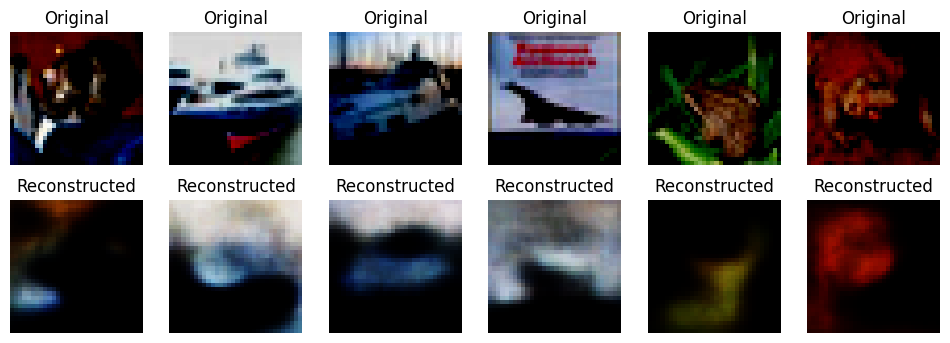

In [15]:
import matplotlib.pyplot as plt

dataiter = iter(test_loader)
images, _ = next(dataiter)

images = images.view(images.size(0), -1)

with torch.no_grad():
    reconstructed, _ = model(images)

images = images.view(-1, 3, 32, 32)
reconstructed = reconstructed.view(-1, 3, 32, 32)

fig, axes = plt.subplots(2, 6, figsize=(12,4))

for i in range(6):
    axes[0,i].imshow(images[i].permute(1,2,0))
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    axes[1,i].imshow(reconstructed[i].permute(1,2,0))
    axes[1,i].set_title("Reconstructed")
    axes[1,i].axis("off")

plt.show()

# Visualizing what each hidden neuron in the sparse autoencoder actually learns

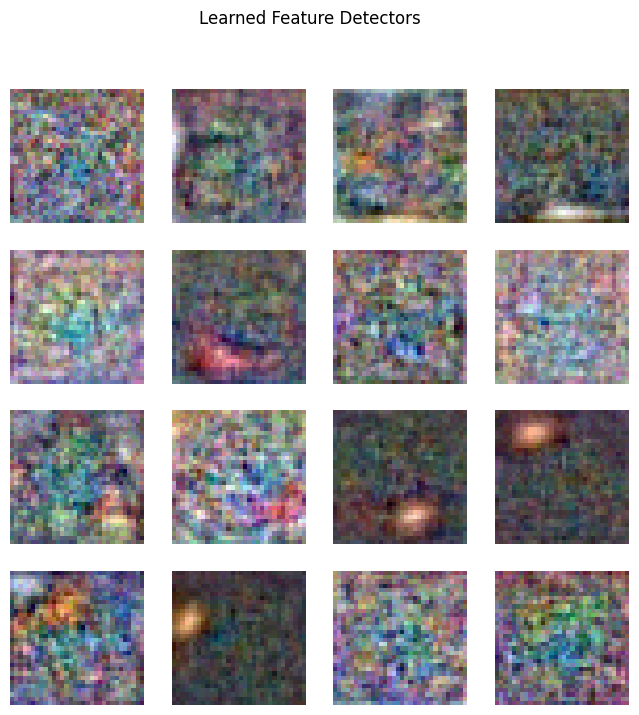

In [16]:
import matplotlib.pyplot as plt

# get weights of first encoder layer
weights = model.encoder[0].weight.data.cpu()

# select first 16 neurons
num_filters = 16

fig, axes = plt.subplots(4,4, figsize=(8,8))

for i in range(num_filters):

    w = weights[i]

    # reshape to image
    w = w.view(3,32,32)

    # normalize for visualization
    w = (w - w.min()) / (w.max() - w.min())

    axes[i//4, i%4].imshow(w.permute(1,2,0))
    axes[i//4, i%4].axis("off")

plt.suptitle("Learned Feature Detectors")
plt.show()